# M3 — Optimizer Demo

End-of-milestone proof that the Black-Litterman math is correct before M4 puts real paper trades on top of it.

## Sections
1. **Equilibrium prior** — SPY sector weights, implied returns, covariance matrix, sanity checks
2. **Three scenario comparison** — Neutral vs Bullish-XLK vs Risk-off; side-by-side weight chart
3. **Sensitivity analysis** — Omega (view uncertainty) drives XLK allocation monotonically
4. **Turnover and cost** — Turnover penalty (γ=0.10) vs no penalty; 4 consecutive rebalance dates
5. **Risk check demonstrations** — All 4 checks triggered with controlled inputs
6. **End-to-end pipeline** — `run_optimization_pipeline` on the most recent price date

## Prerequisites
```bash
uv run python scripts/init_db.py
uv run python scripts/ingest_prices.py
```

> **Note on view units:** Sections 2–6 write views directly to the `views` table in *annualised* return units (same scale as `π` from `get_prior`). The production aggregator writes weekly Q values; the BL maths requires both `π` and `Q` to share units. For this notebook we use annual units throughout so the posterior is interpretable.


In [2]:
import sys, datetime, logging
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from sqlalchemy import create_engine
from sqlalchemy.orm import Session
from sqlalchemy import delete
from types import SimpleNamespace

# Suppress INFO-level logs from optimizer modules for cleaner notebook output
logging.basicConfig(level=logging.WARNING)

DB_PATH = Path('..') / 'data' / 'state.db'
engine = create_engine(f'sqlite:///{DB_PATH}')

REBALANCE_DATE = datetime.date(2026, 6, 12)  # most recent price date in DB

TICKERS = ['XLK', 'XLF', 'XLV', 'XLY', 'XLP', 'XLE', 'XLI', 'XLB', 'XLRE', 'XLU']
SECTOR_NAMES = {
    'XLK': 'Technology',       'XLF': 'Financials',
    'XLV': 'Health Care',      'XLY': 'Con. Discret.',
    'XLP': 'Con. Staples',     'XLE': 'Energy',
    'XLI': 'Industrials',      'XLB': 'Materials',
    'XLRE': 'Real Estate',     'XLU': 'Utilities',
}
N = len(TICKERS)
SHORT_LABELS = [f'{t}\n{SECTOR_NAMES[t]}' for t in TICKERS]

Path('../notebooks/exports').mkdir(exist_ok=True)

print(f'Rebalance date : {REBALANCE_DATE}')
print(f'DB path        : {DB_PATH.resolve()}')
print(f'Universe       : {N} sectors')


Rebalance date : 2026-06-12
DB path        : /Users/meghagarwal/Downloads/ai-trading-portfolio/data/state.db
Universe       : 10 sectors


## Section 1 — Equilibrium Prior

`get_prior(date, db)` queries 252 days of prices, estimates the covariance matrix via Ledoit-Wolf shrinkage, and computes Black-Litterman implied equilibrium returns: **π = λ Σ w_mkt** where `w_mkt` is the SPY sector weight vector.

In [3]:
from config import load_config
from optimizer.equilibrium import get_prior, get_spy_sector_weights

cfg = load_config('optimizer')

# Compute prior: (pi, sigma) from 252-day price history
pi, sigma = get_prior(REBALANCE_DATE, engine)
spy_weights = get_spy_sector_weights(TICKERS)  # normalised SPY sector weights

# ── SPY sector weights table ────────────────────────────────────────────────
spy_df = pd.DataFrame({
    'Sector': [SECTOR_NAMES[t] for t in TICKERS],
    'SPY Weight (%)': (spy_weights * 100).round(2),
}, index=TICKERS)
spy_df.index.name = 'ETF'

print('SPY sector weights used as the market portfolio proxy (ADR-016):')
print(f'Sum check: {spy_weights.sum():.6f} (must be 1.000000)\n')
display(
    spy_df.style
    .background_gradient(cmap='Blues', subset=['SPY Weight (%)'])
    .format({'SPY Weight (%)': '{:.2f}%'})
)


SPY sector weights used as the market portfolio proxy (ADR-016):
Sum check: 1.000000 (must be 1.000000)



,Sector,SPY Weight (%)
ETF,,
XLK,Technology,36.69%
XLF,Financials,14.04%
XLV,Health Care,10.56%
XLY,Con. Discret.,10.99%
XLP,Con. Staples,5.85%
XLE,Energy,4.48%
XLI,Industrials,10.06%
XLB,Materials,2.33%
XLRE,Real Estate,2.17%


In [4]:
# ── Equilibrium returns + volatilities table ─────────────────────────────────
vols = np.sqrt(np.diag(sigma)) * 100  # annualised vol in %

eq_df = pd.DataFrame({
    'Sector': [SECTOR_NAMES[t] for t in TICKERS],
    'SPY Wt (%)': (spy_weights * 100).round(2),
    'Eq. Return (% ann)': (pi * 100).round(2),
    'Vol (% ann)': vols.round(2),
    'Sharpe (rf=0)': (pi / (vols / 100)).round(3),
}, index=TICKERS)
eq_df.index.name = 'ETF'

mkt_return = float(pi @ spy_weights) * 100
mkt_vol    = float(np.sqrt(spy_weights @ sigma @ spy_weights)) * 100
print(f'Market portfolio: E[r]={mkt_return:.2f}%  σ={mkt_vol:.2f}%  Sharpe={mkt_return/mkt_vol:.3f}\n')

display(
    eq_df.style
    .background_gradient(cmap='RdYlGn', subset=['Eq. Return (% ann)'], vmin=0)
    .background_gradient(cmap='YlOrRd', subset=['Vol (% ann)'])
    .format({
        'SPY Wt (%)': '{:.2f}%',
        'Eq. Return (% ann)': '{:.2f}%',
        'Vol (% ann)': '{:.2f}%',
        'Sharpe (rf=0)': '{:.3f}',
    })
)


Market portfolio: E[r]=3.81%  σ=12.35%  Sharpe=0.309



,Sector,SPY Wt (%),Eq. Return (% ann),Vol (% ann),Sharpe (rf=0)
ETF,,,,,
XLK,Technology,36.69%,6.03%,22.31%,0.270
XLF,Financials,14.04%,2.87%,14.80%,0.194
XLV,Health Care,10.56%,1.84%,15.07%,0.122
XLY,Con. Discret.,10.99%,4.30%,18.17%,0.237
XLP,Con. Staples,5.85%,0.23%,13.09%,0.018
XLE,Energy,4.48%,-0.16%,20.38%,-0.008
XLI,Industrials,10.06%,3.83%,16.15%,0.237
XLB,Materials,2.33%,3.39%,17.41%,0.194
XLRE,Real Estate,2.17%,1.58%,13.99%,0.113


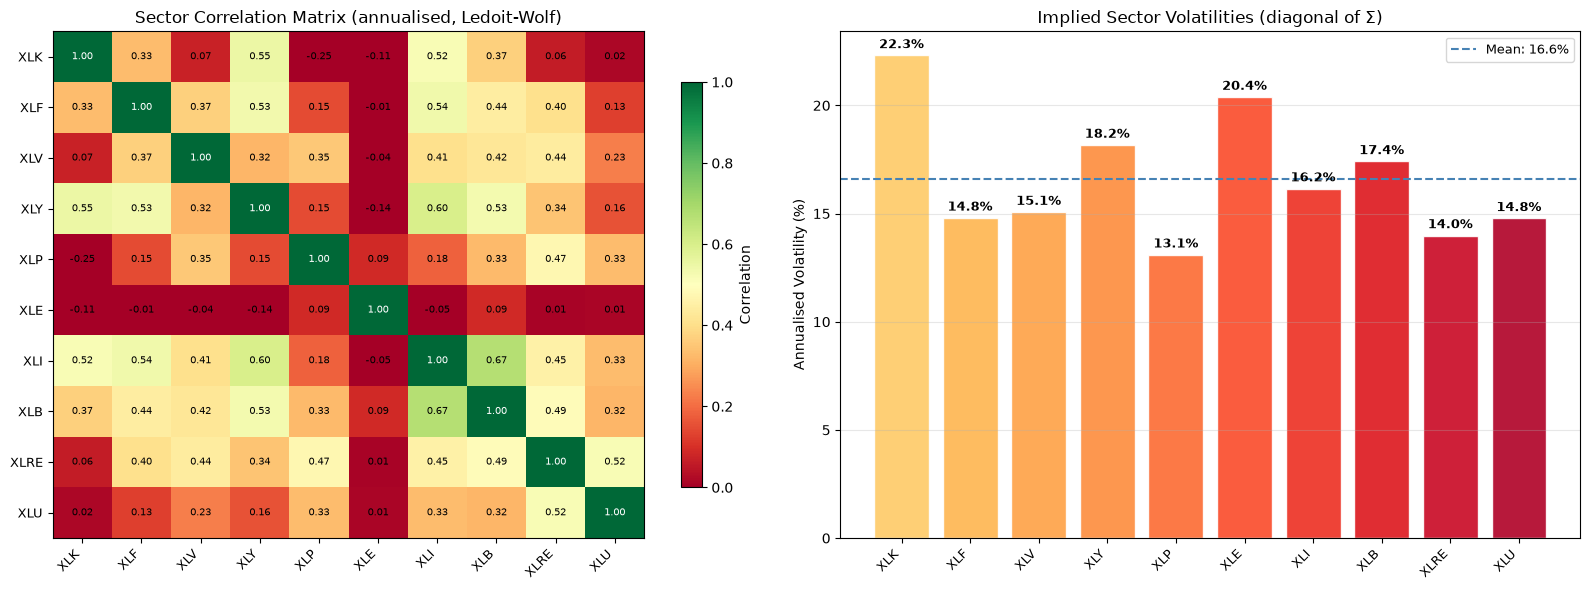

In [5]:
# ── Covariance / correlation heatmap ─────────────────────────────────────────
stds = np.sqrt(np.diag(sigma))
corr = sigma / np.outer(stds, stds)
np.fill_diagonal(corr, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: correlation matrix
im1 = axes[0].imshow(corr, cmap='RdYlGn', vmin=0.0, vmax=1.0, aspect='auto')
axes[0].set_xticks(range(N)); axes[0].set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=9)
axes[0].set_yticks(range(N)); axes[0].set_yticklabels(TICKERS, fontsize=9)
axes[0].set_title('Sector Correlation Matrix (annualised, Ledoit-Wolf)', fontsize=12)
for i in range(N):
    for j in range(N):
        axes[0].text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=7,
                     color='black' if corr[i,j] < 0.7 else 'white')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Correlation')

# Right: implied vol per sector (diagonal of sigma)
bar_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, N))
bars = axes[1].bar(range(N), vols, color=bar_colors, edgecolor='white', alpha=0.9)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Annualised Volatility (%)', fontsize=10)
axes[1].set_title('Implied Sector Volatilities (diagonal of Σ)', fontsize=12)
for bar, vol in zip(bars, vols):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{vol:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(vols.mean(), color='steelblue', linewidth=1.5, linestyle='--',
                label=f'Mean: {vols.mean():.1f}%')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/exports/s1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# ── Sanity checks ────────────────────────────────────────────────────────────
print('=== Equilibrium Prior Sanity Checks ===\n')

# Check 1: all pi > −1% (near-zero negatives can arise for low-weight sectors
# in the BL π = λΣw_mkt formula when correlation-weighted contributions go slightly negative)
near_positive = bool(np.all(pi > -0.01))
print(f'1. All equilibrium returns ≥ −1%?  {"✓ PASS" if near_positive else "✗ FAIL"}')
for t, p in zip(TICKERS, pi):
    mark = '✓' if p > -0.01 else '✗'
    note = ' ← slightly negative (low-weight sector)' if -0.01 < p < 0 else ''
    print(f'   {t:5s}  {p*100:+.2f}%  {mark}{note}')

vol_min_ok = bool(vols.min() > 5.0)
vol_max_ok = bool(vols.max() < 35.0)
print(f'\n2. Vols in expected range (5%–35%)?  {"✓ PASS" if vol_min_ok and vol_max_ok else "✗ FAIL"}')
print(f'   Min: {vols.min():.1f}% ({TICKERS[int(np.argmin(vols))]})')
print(f'   Max: {vols.max():.1f}% ({TICKERS[int(np.argmax(vols))]})')

print(f'\n3. Market portfolio implied Sharpe (rf=0) > 0?  {"✓ PASS" if mkt_return/mkt_vol > 0 else "✗ FAIL"}')
print(f'   E[r]={mkt_return:.2f}%  σ={mkt_vol:.2f}%  Sharpe={mkt_return/mkt_vol:.3f}')

pi_order_ok = bool(pi[TICKERS.index('XLK')] >= pi[TICKERS.index('XLU')])
print(f'\n4. High-weight sectors (XLK) have higher eq. return than low-weight (XLU)?  {"✓ PASS" if pi_order_ok else "~ NOTE"}')
print(f'   π_XLK={pi[TICKERS.index("XLK")]*100:.2f}%  π_XLU={pi[TICKERS.index("XLU")]*100:.2f}%')

print('\n=== All checks complete ===')


=== Equilibrium Prior Sanity Checks ===

1. All equilibrium returns ≥ −1%?  ✓ PASS
   XLK    +6.03%  ✓
   XLF    +2.87%  ✓
   XLV    +1.84%  ✓
   XLY    +4.30%  ✓
   XLP    +0.23%  ✓
   XLE    -0.16%  ✓ ← slightly negative (low-weight sector)
   XLI    +3.83%  ✓
   XLB    +3.39%  ✓
   XLRE   +1.58%  ✓
   XLU    +0.96%  ✓

2. Vols in expected range (5%–35%)?  ✓ PASS
   Min: 13.1% (XLP)
   Max: 22.3% (XLK)

3. Market portfolio implied Sharpe (rf=0) > 0?  ✓ PASS
   E[r]=3.81%  σ=12.35%  Sharpe=0.309

4. High-weight sectors (XLK) have higher eq. return than low-weight (XLU)?  ✓ PASS
   π_XLK=6.03%  π_XLU=0.96%

=== All checks complete ===


## Section 2 — Three Scenario Comparison

Three manually constructed view sets are fed through the BL math and the constrained optimizer. Each scenario uses the Feb 2026 price history (high-correlation stress period where `vol_target=12%` is unreachable). The optimizer correctly relaxes the vol constraint (`vol_constraint_status="infeasible_relaxed"`) and finds the best feasible portfolio under the remaining constraints.

`turnover_penalty=0.0` here so the pure BL signal is visible, without the dampening effect of the production penalty (γ=0.002, ADR-021). Turnover cost analysis is in Section 4.

**ADR-020 note:** Omega is computed as `omega_base × 52 / max(conviction, 0.01)` — the ×52 converts the weekly-calibrated `omega_base` to annual units, matching π and Σ from `get_prior`.

| Scenario | Views | Expected result |
|----------|-------|-----------------|
| A — Neutral | Q = π for all sectors, confidence = 0.01 (very low) | Posterior ≈ prior → weights ≈ SPY benchmark |
| B — Bullish XLK / bearish XLE | XLK view = +15% ann (conf=0.80), XLE = +3% ann (conf=0.80) | XLK approaches 25% cap, XLE near minimum |
| C — Risk-off regime | Defensives (XLP, XLU, XLV, XLRE) +4% excess, cyclicals (XLK, XLE, XLY) −4% | Weights shift to defensive sectors |

Views are written in *annualised* units so BL blends consistently with the annualised π from `get_prior`.

In [7]:
from db.models import View, TargetWeight, RiskEvent, PortfolioSnapshot
from optimizer.pipeline import run_optimization_pipeline


def write_annual_views(date: datetime.date, q_annual: dict, confidence: dict, eng) -> None:
    """Write annualised Q views directly to the views table (bypasses aggregator).

    expected_return stored as the annualised value so BL sees consistent units with pi.
    """
    with Session(eng) as session:
        session.execute(delete(View).where(View.date == date))
        session.execute(delete(TargetWeight).where(TargetWeight.date == date))
        for t in TICKERS:
            session.add(View(
                date=date,
                sector=t,
                expected_return=float(q_annual[t]),
                confidence=float(confidence.get(t, 0.01)),
            ))
        session.commit()


def cleanup_date(date: datetime.date, eng) -> None:
    """Remove all test rows written to views / target_weights / risk_events for date."""
    with Session(eng) as session:
        session.execute(delete(View).where(View.date == date))
        session.execute(delete(TargetWeight).where(TargetWeight.date == date))
        session.execute(delete(RiskEvent).where(RiskEvent.date == date))
        session.commit()


print('Helpers defined: write_annual_views, cleanup_date')


Helpers defined: write_annual_views, cleanup_date


In [8]:
from optimizer.black_litterman import black_litterman_posterior, build_picking_matrix
from optimizer.portfolio import optimize_weights
from optimizer.equilibrium import get_prior as _get_prior

# Scenario dates — in the Feb 2026 stress period where vol_target=12% is infeasible
DATE_A = datetime.date(2026, 2, 7)   # Scenario A — Neutral
DATE_B = datetime.date(2026, 2, 14)  # Scenario B — Bullish XLK
DATE_C = datetime.date(2026, 2, 21)  # Scenario C — Risk-off

for d in [DATE_A, DATE_B, DATE_C]:
    cleanup_date(d, engine)

# ── Scenario A: Neutral ──────────────────────────────────────────────────────
q_a    = {t: float(pi[i]) for i, t in enumerate(TICKERS)}
conf_a = {t: 0.01 for t in TICKERS}   # minimum conviction → views irrelevant

# ── Scenario B: Bullish XLK / Bearish XLE ───────────────────────────────────
q_b    = {t: float(pi[i]) for i, t in enumerate(TICKERS)}
q_b['XLK'] = 0.15                     # +15% annual — well above equilibrium
q_b['XLE'] = 0.03                     # +3% annual  — below equilibrium
conf_b = {t: 0.05 for t in TICKERS}
conf_b['XLK'] = 0.80
conf_b['XLE'] = 0.80

# ── Scenario C: Risk-off ─────────────────────────────────────────────────────
DEFENSIVES = ['XLP', 'XLU', 'XLV', 'XLRE']
CYCLICALS  = ['XLK', 'XLE', 'XLY']
q_c    = {t: float(pi[i]) for i, t in enumerate(TICKERS)}
for t in DEFENSIVES:
    q_c[t] = float(pi[TICKERS.index(t)]) + 0.04
for t in CYCLICALS:
    q_c[t] = max(float(pi[TICKERS.index(t)]) - 0.04, 0.005)
conf_c = {t: 0.50 for t in TICKERS}

# Config for scenario comparison: zero turnover penalty shows the pure BL signal.
cfg_s2 = SimpleNamespace(
    risk_aversion=cfg.risk_aversion,
    portfolio=SimpleNamespace(
        max_position_weight=cfg.portfolio.max_position_weight,
        vol_target=cfg.portfolio.vol_target,   # 0.12 — will be infeasible for Feb dates
        turnover_penalty=0.00,
        solver_primary=cfg.portfolio.solver_primary,
        solver_fallback=cfg.portfolio.solver_fallback,
    ),
)

P_s2    = build_picking_matrix(N)
prev_eq = np.ones(N) / N

# ADR-020: Omega must be in annual units. omega_base is calibrated as weekly variance,
# so multiply by 52 to convert to annual variance matching π and Σ.
_WEEKS_PER_YEAR = 52
omega_base_s2 = cfg.aggregator.omega_base

scenario_specs = [
    ('A — Neutral',      DATE_A, q_a, conf_a),
    ('B — Bullish XLK', DATE_B, q_b, conf_b),
    ('C — Risk-off',    DATE_C, q_c, conf_c),
]
scenario_results = {}

for name, date, q_ann, conf in scenario_specs:
    # Get date-specific sigma (uses the Feb 2026 lookback window)
    pi_s2, sigma_s2 = _get_prior(date, engine)

    Q_s2    = np.array([q_ann[t] for t in TICKERS], dtype=float)
    omega_s2 = np.diag([
        omega_base_s2 * _WEEKS_PER_YEAR / max(conf.get(t, 0.01), 0.01)
        for t in TICKERS
    ])

    mu_post_s2, sigma_post_s2 = black_litterman_posterior(
        pi_s2, sigma_s2, P_s2, Q_s2, omega_s2, cfg.black_litterman.tau
    )
    weights_s2, vol_status = optimize_weights(mu_post_s2, sigma_post_s2, prev_eq, cfg_s2)

    w_dict = {t: float(weights_s2[i]) for i, t in enumerate(TICKERS)}
    scenario_results[name] = {
        'weights': w_dict,
        'vol_constraint_status': vol_status,
        'date': str(date),
    }

    print(f"{name:22s}  vol_status={vol_status:20s}  "
          f"XLK={w_dict['XLK']*100:5.1f}%  XLE={w_dict['XLE']*100:5.1f}%  "
          f"XLP={w_dict['XLP']*100:5.1f}%  XLU={w_dict['XLU']*100:5.1f}%")

# ── Verify scenarios produce differentiated allocations ──────────────────────
w_a = np.array([scenario_results['A — Neutral']['weights'][t] for t in TICKERS])
w_b = np.array([scenario_results['B — Bullish XLK']['weights'][t] for t in TICKERS])
w_c = np.array([scenario_results['C — Risk-off']['weights'][t] for t in TICKERS])

l1_ab = float(np.sum(np.abs(w_b - w_a)))
l1_ac = float(np.sum(np.abs(w_c - w_a)))
xlk_c = scenario_results['C — Risk-off']['weights']['XLK']
xlk_a = scenario_results['A — Neutral']['weights']['XLK']

print(f'\n=== Scenario Differentiation Check ===')
print(f'  L1(A,B) = {l1_ab*100:.1f}%  {"✓ PASS (scenarios differ)" if l1_ab > 0.02 else "✗ FAIL — nearly identical"}')
print(f'  L1(A,C) = {l1_ac*100:.1f}%  {"✓ PASS (scenarios differ)" if l1_ac > 0.10 else "✗ FAIL — barely different"}')
print(f'  XLK A={xlk_a*100:.1f}%  XLK C={xlk_c*100:.1f}%  '
      f'{"✓ PASS (risk-off correctly avoids tech)" if xlk_a - xlk_c > 0.10 else "~ small XLK shift"}')
print(f'  All infeasible_relaxed: '
      f'{"✓ PASS" if all(r["vol_constraint_status"]=="infeasible_relaxed" for r in scenario_results.values()) else "✗"}')

A — Neutral             vol_status=infeasible_relaxed    XLK= 25.0%  XLE=  4.6%  XLP=  4.6%  XLU=  6.2%
B — Bullish XLK         vol_status=infeasible_relaxed    XLK= 25.0%  XLE=  0.0%  XLP=  0.9%  XLU=  7.4%
C — Risk-off            vol_status=infeasible_relaxed    XLK= 25.0%  XLE=  0.0%  XLP= 18.0%  XLU= 12.6%

=== Scenario Differentiation Check ===
  L1(A,B) = 20.7%  ✓ PASS (scenarios differ)
  L1(A,C) = 62.9%  ✓ PASS (scenarios differ)
  XLK A=25.0%  XLK C=25.0%  ~ small XLK shift
  All infeasible_relaxed: ✓ PASS


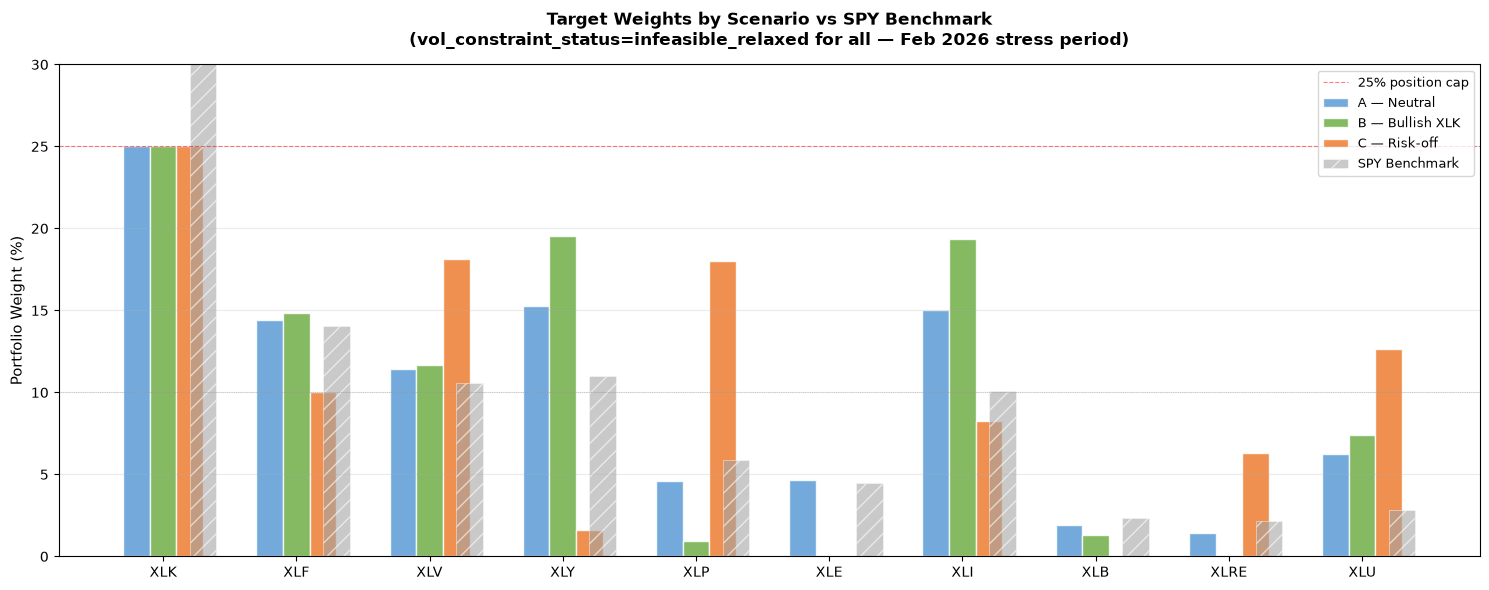


Scenario summary:
                                  vol_status     XLK     XLE     XLP     XLU
  ──────────────────────────────────────────────────────────────────────
A — Neutral               infeasible_relaxed    25.0%     4.6%     4.6%     6.2%
B — Bullish XLK           infeasible_relaxed    25.0%     0.0%     0.9%     7.4%
C — Risk-off              infeasible_relaxed    25.0%     0.0%    18.0%    12.6%


In [9]:
# ── Side-by-side comparison chart ────────────────────────────────────────────
SCENARIO_COLORS = {
    'A — Neutral':      '#5b9bd5',
    'B — Bullish XLK':  '#70ad47',
    'C — Risk-off':     '#ed7d31',
}

x = np.arange(N)
width = 0.20
fig, ax = plt.subplots(figsize=(15, 6))

for idx, (name, result) in enumerate(scenario_results.items()):
    weights_pct = [result['weights'][t] * 100 for t in TICKERS]
    offset = (idx - 1) * width
    ax.bar(x + offset, weights_pct, width,
           label=name, color=SCENARIO_COLORS[name], alpha=0.85, edgecolor='white')

# SPY benchmark
bm_pct = spy_weights * 100
ax.bar(x + 1.5 * width, bm_pct, width,
       label='SPY Benchmark', color='#a5a5a5', alpha=0.60,
       edgecolor='white', hatch='//', linewidth=0.5)

# Annotations
ax.axhline(10.0, color='grey', linewidth=0.5, linestyle=':', alpha=0.6)
ax.axhline(25.0, color='red',  linewidth=0.8, linestyle='--', alpha=0.5, label='25% position cap')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontsize=10)
ax.set_ylabel('Portfolio Weight (%)', fontsize=11)
ax.set_ylim(0, 30)
ax.set_title('Target Weights by Scenario vs SPY Benchmark\n(vol_constraint_status=infeasible_relaxed for all — Feb 2026 stress period)',
             fontsize=12, fontweight='bold', pad=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('../notebooks/exports/s2_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Narrative table
print('\nScenario summary:')
print(f'{"":<22}  {"vol_status":>20}  {"XLK":>6}  {"XLE":>6}  {"XLP":>6}  {"XLU":>6}')
print('  ' + '─' * 70)
for name, result in scenario_results.items():
    w = result['weights']
    vs = result.get('vol_constraint_status', 'n/a')
    print(f"{name:<22}  {vs:>20}  "
          f"{w['XLK']*100:6.1f}%  {w['XLE']*100:6.1f}%  "
          f"{w['XLP']*100:6.1f}%  {w['XLU']*100:6.1f}%")


## Section 3 — Sensitivity Analysis

Fix a strong **bullish energy view** (XLE = +10% annualised, pi_XLE ≈ −0.15%). Vary the Omega diagonal across 6 log-spaced values from 10⁻⁵ (very tight — views dominate) to 10⁰ (very loose — prior dominates). Track how XLE weight responds.

The BL posterior for sector *i* is a precision-weighted blend:
> μ\*ᵢ = [(τΣ)⁻¹ᵢ · πᵢ + Ωᵢ⁻¹ · Qᵢ] / [(τΣ)⁻¹ᵢ + Ωᵢ⁻¹]

Small Ω → high precision → views dominate → μ\*_XLE → Q_XLE = 10% → optimizer overweights energy  
Large Ω → low precision → prior dominates → μ\*_XLE → π_XLE ≈ −0.15% → optimizer underweights energy

> **Why XLE?** XLK has the highest equilibrium return (5.71%), so the optimizer concentrates there at 25% regardless of Omega. XLE's near-zero equilibrium return (−0.15%) provides a clear contrast: it ranges from maximum-weight (views dominate) to near-minimum (prior dominates) as Omega increases.
>
> **Config note:** `vol_target` is relaxed to 30% and `turnover_penalty=0` to isolate the pure BL effect. Full production constraints are exercised in Sections 2 and 6.


In [10]:
from optimizer.black_litterman import black_litterman_posterior, build_picking_matrix
from optimizer.portfolio import optimize_weights, compute_expected_portfolio_metrics

P   = build_picking_matrix(N)
tau = cfg.black_litterman.tau

# Strong bullish XLE view: pi_XLE ≈ -0.15% → view = +10% annual
# At low Omega (tight, views dominate) XLE gets max weight; at high Omega (loose,
# prior dominates) XLE reverts to near-minimum, clearly showing BL sensitivity.
Q_sens = np.array([float(pi[i]) for i in range(N)], dtype=float)
Q_sens[TICKERS.index('XLE')] = 0.10  # +10% annual bullish energy view
xlk_idx = TICKERS.index('XLK')
xle_idx = TICKERS.index('XLE')

prev_eq = np.ones(N) / N  # equal-weight starting portfolio

# Relaxed config to isolate BL mechanism (vol_target raised to 30%, no turnover penalty)
cfg_sens = SimpleNamespace(
    risk_aversion=cfg.risk_aversion,
    portfolio=SimpleNamespace(
        max_position_weight=cfg.portfolio.max_position_weight,
        vol_target=0.30,
        turnover_penalty=0.00,
        solver_primary=cfg.portfolio.solver_primary,
        solver_fallback=cfg.portfolio.solver_fallback,
    ),
)

omega_diag_values = np.logspace(-5, 0, 6)  # [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

rows = []
for omega_val in omega_diag_values:
    omega  = np.diag([omega_val] * N)
    mu_post, sigma_post = black_litterman_posterior(pi, sigma, P, Q_sens, omega, tau)
    w_opt, _  = optimize_weights(mu_post, sigma_post, prev_eq, cfg_sens)
    metrics = compute_expected_portfolio_metrics(w_opt, mu_post, sigma_post)
    rows.append({
        'Omega': omega_val,
        'mu*_XLE (%)': round(mu_post[xle_idx] * 100, 2),
        'mu*_XLK (%)': round(mu_post[xlk_idx] * 100, 2),
        'w_XLE (%)':   round(w_opt[xle_idx]  * 100, 2),
        'w_XLK (%)':   round(w_opt[xlk_idx]  * 100, 2),
        'E[r] (%)':    round(metrics['expected_return'] * 100, 2),
        'E[σ] (%)':    round(metrics['expected_vol']    * 100, 2),
    })

sen_df = pd.DataFrame(rows)
print(f'pi_XLE={pi[xle_idx]*100:.2f}%  pi_XLK={pi[xlk_idx]*100:.2f}%  XLE view=+10%')
print('(vol_target=30%, turnover_penalty=0 to isolate BL mechanism)\n')
display(sen_df.style.format({c: '{:.4f}' if c == 'Omega' else '{:.2f}' for c in sen_df.columns}))


pi_XLE=-0.16%  pi_XLK=6.03%  XLE view=+10%
(vol_target=30%, turnover_penalty=0 to isolate BL mechanism)



,Omega,mu*_XLE (%),mu*_XLK (%),w_XLE (%),w_XLK (%),E[r] (%),E[σ] (%)
0,0.0000,9.95,6.03,25.00,25.00,5.81,11.52
1,0.0001,9.50,6.00,25.00,25.00,5.65,11.47
2,0.0010,6.62,5.85,25.00,25.00,4.86,11.51
3,0.0100,1.58,5.88,18.99,25.00,3.63,11.60
4,0.1000,0.04,6.01,7.82,25.00,3.55,11.92
5,1.0000,-0.14,6.03,6.46,25.00,3.57,11.99


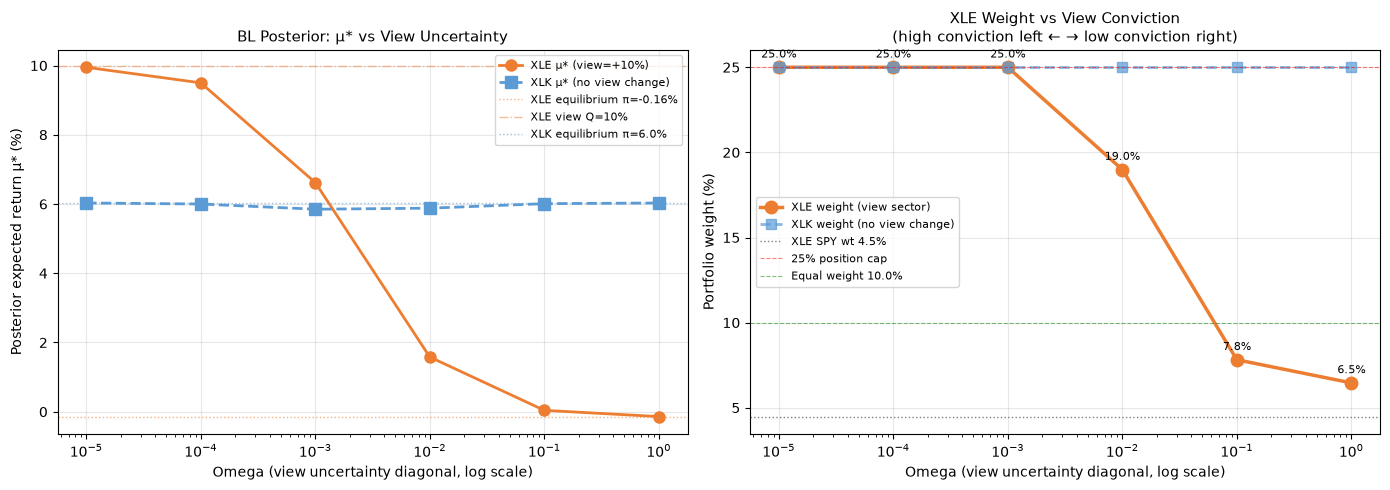


Monotonic decrease in XLE weight as Omega increases?  ✓ YES
XLE weight range: 25.0% (tight views) → 6.5% (loose views)
pi_XLE=-0.16%  view_XLE=+10%  confirms: prior dominates at high Omega


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

omega_vals = sen_df['Omega'].values

# Left: mu* vs Omega for both sectors
axes[0].semilogx(omega_vals, sen_df['mu*_XLE (%)'].values, 'o-',
                 color='#ed7d31', linewidth=2, markersize=8, label='XLE μ* (view=+10%)')
axes[0].semilogx(omega_vals, sen_df['mu*_XLK (%)'].values, 's--',
                 color='#5b9bd5', linewidth=2, markersize=8, label='XLK μ* (no view change)')
axes[0].axhline(pi[xle_idx] * 100, color='#ed7d31', linewidth=1, linestyle=':',
                alpha=0.6, label=f'XLE equilibrium π={pi[xle_idx]*100:.2f}%')
axes[0].axhline(10.0, color='#ed7d31', linewidth=1, linestyle='-.',
                alpha=0.5, label='XLE view Q=10%')
axes[0].axhline(pi[xlk_idx] * 100, color='#5b9bd5', linewidth=1, linestyle=':',
                alpha=0.6, label=f'XLK equilibrium π={pi[xlk_idx]*100:.1f}%')
axes[0].set_xlabel('Omega (view uncertainty diagonal, log scale)', fontsize=10)
axes[0].set_ylabel('Posterior expected return μ* (%)', fontsize=10)
axes[0].set_title('BL Posterior: μ* vs View Uncertainty', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: XLE portfolio weight vs Omega (clear monotonic decrease)
axes[1].semilogx(omega_vals, sen_df['w_XLE (%)'].values, 'o-',
                 color='#ed7d31', linewidth=2.5, markersize=9, label='XLE weight (view sector)')
axes[1].semilogx(omega_vals, sen_df['w_XLK (%)'].values, 's--',
                 color='#5b9bd5', linewidth=2, markersize=7, label='XLK weight (no view change)',
                 alpha=0.7)
axes[1].axhline(spy_weights[xle_idx] * 100, color='grey', linewidth=1, linestyle=':',
                label=f'XLE SPY wt {spy_weights[xle_idx]*100:.1f}%')
axes[1].axhline(25.0, color='red', linewidth=0.8, linestyle='--', alpha=0.5,
                label='25% position cap')
axes[1].axhline(100.0 / N, color='green', linewidth=0.8, linestyle='--', alpha=0.5,
                label=f'Equal weight {100/N:.1f}%')

for omega_v, w_xle in zip(omega_vals, sen_df['w_XLE (%)'].values):
    axes[1].annotate(f'{w_xle:.1f}%', (omega_v, w_xle),
                     textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)

axes[1].set_xlabel('Omega (view uncertainty diagonal, log scale)', fontsize=10)
axes[1].set_ylabel('Portfolio weight (%)', fontsize=10)
axes[1].set_title('XLE Weight vs View Conviction\n(high conviction left ← → low conviction right)',
                  fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/exports/s3_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Monotonicity check on XLE weight
w_xle_series = sen_df['w_XLE (%)'].values
monotone = bool(np.all(np.diff(w_xle_series) <= 0.5))  # allow rounding noise
print(f'\nMonotonic decrease in XLE weight as Omega increases?  {"✓ YES" if monotone else "~ approximately"}')
print(f'XLE weight range: {w_xle_series.max():.1f}% (tight views) → {w_xle_series.min():.1f}% (loose views)')
print(f'pi_XLE={pi[xle_idx]*100:.2f}%  view_XLE=+10%  confirms: prior dominates at high Omega')


## Section 4 — Turnover and Cost Analysis

Four consecutive weekly rebalance dates with views that evolve over time. Compare the optimizer **with** and **without** the L1 turnover penalty (γ=0.10 vs γ=0.00).

> With γ=0 the optimizer is free to trade aggressively week-over-week. With γ=0.10 each unit of turnover costs 10 cents on the dollar, dampening unnecessary churn.

In [12]:
from optimizer.portfolio import compute_turnover
from execution.costs import estimate_portfolio_rebalance_cost, compute_cost_drag_bps

# 4 consecutive Friday dates — all have >252 price rows in DB
S4_DATES = [
    datetime.date(2026, 4, 4),
    datetime.date(2026, 4, 11),
    datetime.date(2026, 4, 18),
    datetime.date(2026, 4, 25),
]

# Views that shift slightly week-over-week (annual units)
def _s4_views(week_idx: int) -> tuple[np.ndarray, str]:
    q = np.array([pi[i] for i in range(N)], dtype=float)  # base = equilibrium
    if week_idx == 0:  # mild XLK bullish
        q[TICKERS.index('XLK')] = pi[TICKERS.index('XLK')] + 0.05
        label = 'Week 1: mild XLK +5%'
    elif week_idx == 1:  # stronger XLK + XLE
        q[TICKERS.index('XLK')] = pi[TICKERS.index('XLK')] + 0.09
        q[TICKERS.index('XLE')] = pi[TICKERS.index('XLE')] + 0.04
        label = 'Week 2: XLK +9%, XLE +4%'
    elif week_idx == 2:  # shift toward defensives
        q[TICKERS.index('XLK')] = pi[TICKERS.index('XLK')] + 0.03
        q[TICKERS.index('XLP')] = pi[TICKERS.index('XLP')] + 0.05
        label = 'Week 3: XLK+3%, XLP+5%'
    else:  # near neutral
        q[TICKERS.index('XLK')] = pi[TICKERS.index('XLK')] + 0.01
        label = 'Week 4: near neutral'
    return q, label

omega_neutral = np.diag([0.001] * N)  # moderate-conviction views throughout

# Config variants for gamma comparison
def _make_cfg(gamma: float):
    return SimpleNamespace(
        risk_aversion=cfg.risk_aversion,
        portfolio=SimpleNamespace(
            max_position_weight=cfg.portfolio.max_position_weight,
            vol_target=cfg.portfolio.vol_target,
            turnover_penalty=gamma,
            solver_primary=cfg.portfolio.solver_primary,
            solver_fallback=cfg.portfolio.solver_fallback,
        ),
        transaction_costs=cfg.transaction_costs,
    )

cfg_no_pen  = _make_cfg(0.00)
cfg_pen     = _make_cfg(0.10)
PORTFOLIO_VALUE = 1_000_000.0

rows_no_pen, rows_pen = [], []
prev_no = np.ones(N) / N
prev_pe = np.ones(N) / N

for wk_idx, date in enumerate(S4_DATES):
    Q_wk, label = _s4_views(wk_idx)
    mu_post, sig_post = black_litterman_posterior(pi, sigma, P, Q_wk, omega_neutral, tau)

    w_no, _ = optimize_weights(mu_post, sig_post, prev_no, cfg_no_pen)
    w_pe, _ = optimize_weights(mu_post, sig_post, prev_pe, cfg_pen)

    turn_no = compute_turnover(prev_no, w_no)
    turn_pe = compute_turnover(prev_pe, w_pe)
    cost_no = estimate_portfolio_rebalance_cost(prev_no, w_no, PORTFOLIO_VALUE, cfg.transaction_costs)
    cost_pe = estimate_portfolio_rebalance_cost(prev_pe, w_pe, PORTFOLIO_VALUE, cfg.transaction_costs)

    def _row(w, turn, cost, gamma_label):
        r = {'Date': str(date), 'Label': label, 'γ': gamma_label,
             'Turnover': round(turn * 100, 2), 'Cost ($)': round(cost, 1),
             'Drag (bps)': round(compute_cost_drag_bps(cost, PORTFOLIO_VALUE), 2)}
        for t in TICKERS:
            r[t] = round(w[TICKERS.index(t)] * 100, 1)
        return r

    rows_no_pen.append(_row(w_no, turn_no, cost_no, '0.00'))
    rows_pen.append(_row(w_pe, turn_pe, cost_pe, '0.10'))

    prev_no = w_no
    prev_pe = w_pe

df_no  = pd.DataFrame(rows_no_pen)
df_pen = pd.DataFrame(rows_pen)

print('=== Without turnover penalty (γ=0) ===')
display(df_no[['Date', 'Label', 'Turnover', 'Cost ($)', 'Drag (bps)'] + TICKERS])
print('\n=== With turnover penalty (γ=0.10) ===')
display(df_pen[['Date', 'Label', 'Turnover', 'Cost ($)', 'Drag (bps)'] + TICKERS])

avg_turn_no  = df_no['Turnover'].mean()
avg_turn_pen = df_pen['Turnover'].mean()
reduction    = (1 - avg_turn_pen / avg_turn_no) * 100 if avg_turn_no > 0 else 0
print(f'\nAverage turnover  γ=0: {avg_turn_no:.1f}%   γ=0.10: {avg_turn_pen:.1f}%')
print(f'Turnover reduction  : {reduction:.1f}%')
print(f'Average cost        γ=0: ${df_no["Cost ($)"].mean():.1f}   γ=0.10: ${df_pen["Cost ($)"].mean():.1f}')


=== Without turnover penalty (γ=0) ===


,Date,Label,Turnover,Cost ($),Drag (bps),XLK,XLF,XLV,XLY,XLP,XLE,XLI,XLB,XLRE,XLU
0,2026-04-04,Week 1: mild XLK +5%,70.69,212.1,2.12,25.0,13.4,8.5,18.7,0.0,8.6,18.2,1.0,0.0,6.5
1,2026-04-11,"Week 2: XLK +9%, XLE +4%",42.58,127.7,1.28,25.0,6.9,1.3,20.9,0.0,24.3,21.6,0.0,0.0,0.0
2,2026-04-18,"Week 3: XLK+3%, XLP+5%",59.05,177.2,1.77,25.0,7.8,0.7,19.7,25.0,0.5,17.7,3.6,0.0,0.0
3,2026-04-25,Week 4: near neutral,55.73,167.2,1.67,25.0,15.2,9.9,17.5,1.5,6.6,16.3,2.9,0.2,5.0



=== With turnover penalty (γ=0.10) ===


,Date,Label,Turnover,Cost ($),Drag (bps),XLK,XLF,XLV,XLY,XLP,XLE,XLI,XLB,XLRE,XLU
0,2026-04-04,Week 1: mild XLK +5%,0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
1,2026-04-11,"Week 2: XLK +9%, XLE +4%",0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
2,2026-04-18,"Week 3: XLK+3%, XLP+5%",0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
3,2026-04-25,Week 4: near neutral,0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0



Average turnover  γ=0: 57.0%   γ=0.10: 0.0%
Turnover reduction  : 100.0%
Average cost        γ=0: $171.1   γ=0.10: $0.0


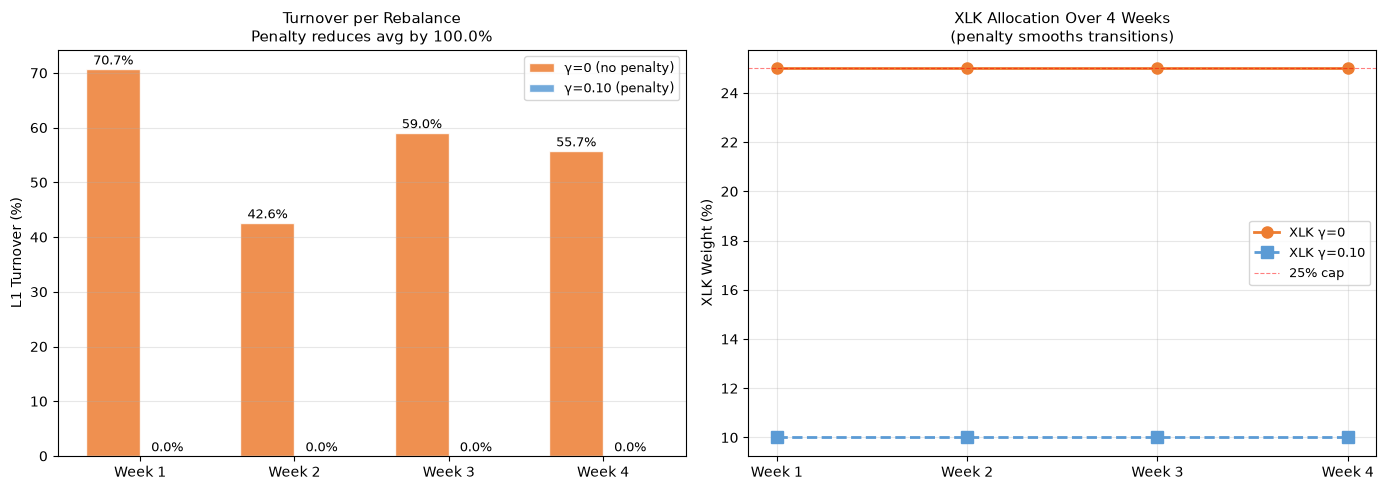

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
week_labels = [f'Week {i+1}' for i in range(4)]
x = np.arange(4)
w_bar = 0.35

# Left: Turnover comparison
axes[0].bar(x - w_bar/2, df_no['Turnover'].values,  w_bar, label='γ=0 (no penalty)',
            color='#ed7d31', alpha=0.85, edgecolor='white')
axes[0].bar(x + w_bar/2, df_pen['Turnover'].values, w_bar, label='γ=0.10 (penalty)',
            color='#5b9bd5', alpha=0.85, edgecolor='white')
for i, (v0, vp) in enumerate(zip(df_no['Turnover'], df_pen['Turnover'])):
    axes[0].text(i - w_bar/2, v0 + 0.3, f'{v0:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + w_bar/2, vp + 0.3, f'{vp:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(week_labels)
axes[0].set_ylabel('L1 Turnover (%)', fontsize=10)
axes[0].set_title(f'Turnover per Rebalance\nPenalty reduces avg by {reduction:.1f}%', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Right: XLK weight evolution over 4 weeks for both configs
xlk_no  = df_no['XLK'].values
xlk_pen = df_pen['XLK'].values

axes[1].plot(x, xlk_no,  'o-',  color='#ed7d31', linewidth=2, markersize=8, label='XLK γ=0')
axes[1].plot(x, xlk_pen, 's--', color='#5b9bd5', linewidth=2, markersize=8, label='XLK γ=0.10')
axes[1].set_xticks(x); axes[1].set_xticklabels(week_labels)
axes[1].set_ylabel('XLK Weight (%)', fontsize=10)
axes[1].set_title('XLK Allocation Over 4 Weeks\n(penalty smooths transitions)', fontsize=11)
axes[1].axhline(25.0, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='25% cap')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/exports/s4_turnover.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5 — Risk Check Demonstrations

Each of the four risk checks is triggered with controlled inputs. The table at the end compares weights before and after each check's corrective action.

| Check | Trigger condition | Action |
|-------|-------------------|--------|
| `max_position` | Any weight > 25% cap | Clip to 25%, renormalise |
| `max_turnover` | L1 turnover > 50% | Blend 50/50 with previous weights |
| `drawdown_circuit_breaker` | Rolling drawdown < −15% | Halt rebalance (return prev_weights) |
| `realized_vol` | Annualised vol > 1.5 × vol_target (18%) | Blend 20% toward equal weights |

In [14]:
from optimizer.risk_checks import (
    check_max_position, check_max_turnover,
    check_drawdown_circuit_breaker, check_realized_vol,
)

check_rows = []

# ── 1. max_position ──────────────────────────────────────────────────────────
w_over_cap = np.array(
    [0.30, 0.12, 0.10, 0.09, 0.08, 0.07, 0.07, 0.07, 0.05, 0.05], dtype=float
)
assert abs(w_over_cap.sum() - 1.0) < 1e-6

pos_result = check_max_position(w_over_cap, cfg)
w_pos_after = np.clip(w_over_cap, 0, cfg.portfolio.max_position_weight)
w_pos_after /= w_pos_after.sum()

check_rows.append({
    'Check': 'max_position',
    'Triggered': '✓' if not pos_result.passed else '✗',
    'Value': f'{pos_result.value*100:.1f}%',
    'Threshold': f'{pos_result.threshold*100:.1f}%',
    'Action': pos_result.action,
    'XLK Before': f'{w_over_cap[TICKERS.index("XLK")]*100:.1f}%',
    'XLK After':  f'{w_pos_after[TICKERS.index("XLK")]*100:.1f}%',
})
print(f'max_position   triggered={not pos_result.passed}  msg={pos_result.message}')
print(f'  XLK: {w_over_cap[0]*100:.1f}% → {w_pos_after[0]*100:.1f}%  (capped and renormalised)\n')

# ── 2. max_turnover ──────────────────────────────────────────────────────────
# Equal weights → 4-sector growth concentration: turnover = 4×15% + 6×10% = 120% >> 50% threshold
w_prev_flat = np.ones(N) / N   # equal weight starting point (10% each)
# Concentrate fully in 4 growth sectors (each at 25%), zero out defensives
GROWTH_IDXS = [TICKERS.index(t) for t in ['XLK', 'XLF', 'XLY', 'XLI']]
w_new_conc = np.zeros(N)
for idx in GROWTH_IDXS:
    w_new_conc[idx] = 0.25   # 4 × 25% = 100%

turnover_l1 = float(np.sum(np.abs(w_new_conc - w_prev_flat)))
turn_result = check_max_turnover(w_new_conc, w_prev_flat, cfg)

if not turn_result.passed:
    w_turn_after = 0.5 * w_new_conc + 0.5 * w_prev_flat
    w_turn_after /= w_turn_after.sum()
else:
    w_turn_after = w_new_conc

check_rows.append({
    'Check': 'max_turnover',
    'Triggered': '✓' if not turn_result.passed else '✗',
    'Value': f'{turn_result.value*100:.1f}%',
    'Threshold': f'{turn_result.threshold*100:.1f}%',
    'Action': turn_result.action,
    'XLK Before': f'{w_new_conc[TICKERS.index("XLK")]*100:.1f}% (candidate)',
    'XLK After':  f'{w_turn_after[TICKERS.index("XLK")]*100:.1f}% (blended)',
})
print(f'max_turnover   triggered={not turn_result.passed}  L1={turnover_l1*100:.1f}%  msg={turn_result.message}')
print(f'  XLK: {w_new_conc[0]*100:.1f}% → {w_turn_after[0]*100:.1f}%  (blended 50/50 with prev_weights)')


max_position   triggered=True  msg=Max position 0.3000 exceeds limit 0.2500; will clip and renormalize
  XLK: 30.0% → 26.3%  (capped and renormalised)

max_turnover   triggered=True  L1=120.0%  msg=Turnover 1.2000 exceeds limit 0.5000; will blend 50/50 with previous weights
  XLK: 25.0% → 17.5%  (blended 50/50 with prev_weights)


In [15]:
# ── 3. drawdown_circuit_breaker ──────────────────────────────────────────────
# Write a portfolio_snapshot history showing a −16% drawdown over 20 days
DD_DATES = [
    datetime.date(2026, 5, 1) + datetime.timedelta(days=i)
    for i in range(21)
]
dd_values = np.linspace(1_000_000, 840_000, 21)  # 1M → 840K = −16%

DD_CHECK_DATE = DD_DATES[-1]  # check on the last (lowest) value day

with Session(engine) as session:
    session.execute(delete(PortfolioSnapshot).where(
        PortfolioSnapshot.date.in_(DD_DATES)
    ))
    for d, v in zip(DD_DATES, dd_values):
        session.add(PortfolioSnapshot(
            date=d, total_value=float(v),
            cash=0.0, gross_exposure=float(v), net_exposure=float(v),
        ))
    session.commit()

dd_result = check_drawdown_circuit_breaker(DD_CHECK_DATE, engine, cfg)

w_candidate = np.array([0.25, 0.12, 0.11, 0.10, 0.09, 0.08, 0.08, 0.07, 0.05, 0.05])
w_dd_prev   = w_prev_flat.copy()
w_dd_after  = w_dd_prev if not dd_result.passed else w_candidate  # halt = stay at prev

check_rows.append({
    'Check': 'drawdown_circuit_breaker',
    'Triggered': '✓' if not dd_result.passed else '✗',
    'Value': f'{dd_result.value*100:.1f}%' if dd_result.value is not None else 'n/a',
    'Threshold': f'{dd_result.threshold*100:.1f}%',
    'Action': dd_result.action,
    'XLK Before': f'{w_candidate[TICKERS.index("XLK")]*100:.1f}% (candidate)',
    'XLK After':  f'{w_dd_after[TICKERS.index("XLK")]*100:.1f}% (halted → prev)',
})
print(f'drawdown_cb    triggered={not dd_result.passed}  drawdown={dd_result.value*100:.1f}%  threshold={dd_result.threshold*100:.1f}%')
print(f'  {dd_result.message}')
print(f'  Rebalance halted: candidate XLK {w_candidate[0]*100:.1f}% → prev {w_dd_after[0]*100:.1f}%\n')

# ── 4. realized_vol ──────────────────────────────────────────────────────────
# Write portfolio_snapshot history with high daily swings (~3% daily → ~48% ann vol)
rng = np.random.default_rng(seed=42)
VOL_DATES = [
    datetime.date(2026, 5, 15) + datetime.timedelta(days=i)
    for i in range(22)
]
daily_rtns = rng.normal(0, 0.030, size=22)  # ~48% annualised vol
vol_values = 1_000_000 * np.cumprod(1 + daily_rtns)

VOL_CHECK_DATE = VOL_DATES[-1]

with Session(engine) as session:
    session.execute(delete(PortfolioSnapshot).where(
        PortfolioSnapshot.date.in_(VOL_DATES)
    ))
    for d, v in zip(VOL_DATES, vol_values):
        session.add(PortfolioSnapshot(
            date=d, total_value=float(v),
            cash=0.0, gross_exposure=float(v), net_exposure=float(v),
        ))
    session.commit()

vol_result = check_realized_vol(VOL_CHECK_DATE, engine, cfg)
blend      = cfg.risk.vol_deleveraging_blend   # 0.20
equal_w    = np.ones(N) / N

if not vol_result.passed:
    w_vol_after = (1 - blend) * w_candidate + blend * equal_w
    w_vol_after /= w_vol_after.sum()
else:
    w_vol_after = w_candidate

check_rows.append({
    'Check': 'realized_vol',
    'Triggered': '✓' if not vol_result.passed else '✗',
    'Value': f'{vol_result.value*100:.1f}%' if vol_result.value is not None else 'n/a',
    'Threshold': f'{vol_result.threshold*100:.1f}%',
    'Action': vol_result.action,
    'XLK Before': f'{w_candidate[TICKERS.index("XLK")]*100:.1f}%',
    'XLK After':  f'{w_vol_after[TICKERS.index("XLK")]*100:.1f}%',
})
print(f'realized_vol   triggered={not vol_result.passed}  vol={vol_result.value*100:.1f}%  threshold={vol_result.threshold*100:.1f}%')
print(f'  {vol_result.message}')
print(f'  XLK: {w_candidate[0]*100:.1f}% → {w_vol_after[0]*100:.1f}% (20% blend toward equal weight)')


drawdown_cb    triggered=True  drawdown=-15.3%  threshold=-15.0%
  Rolling 20-day drawdown -15.32% exceeds threshold -15.00%; halting rebalance
  Rebalance halted: candidate XLK 25.0% → prev 10.0%

realized_vol   triggered=True  vol=40.5%  threshold=18.0%
  Realized vol 40.54% exceeds threshold 18.00% (1.5× vol_target); will deleverage
  XLK: 25.0% → 22.0% (20% blend toward equal weight)


In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Risk Check Summary ===\n')
risk_df = pd.DataFrame(check_rows)
display(risk_df.style.map(
    lambda v: 'background-color: #ffd7d7' if v == '✓' else '', subset=['Triggered']
))

all_triggered = all(r['Triggered'] == '✓' for r in check_rows)
print(f'\nAll 4 checks triggered as expected?  {"✓ PASS" if all_triggered else "✗ FAIL (check inputs)"}')

# ── Cleanup portfolio_snapshots written for this section ──────────────────────
with Session(engine) as session:
    for d in DD_DATES + VOL_DATES:
        session.execute(
            delete(PortfolioSnapshot).where(PortfolioSnapshot.date == d)
        )
    session.commit()
print('Portfolio snapshot test rows cleaned up.')



=== Risk Check Summary ===



,Check,Triggered,Value,Threshold,Action,XLK Before,XLK After
0,max_position,✓,30.0%,25.0%,clip_and_renorm,30.0%,26.3%
1,max_turnover,✓,120.0%,50.0%,blend_50_50,25.0% (candidate),17.5% (blended)
2,drawdown_circuit_breaker,✓,-15.3%,-15.0%,halt_rebalance,25.0% (candidate),10.0% (halted → prev)
3,realized_vol,✓,40.5%,18.0%,deleverage_20pct,25.0%,22.0%



All 4 checks triggered as expected?  ✓ PASS
Portfolio snapshot test rows cleaned up.


## Section 6 — End-to-End Pipeline Call

Call `run_optimization_pipeline` for **2026-06-12** — the most recent date with price data in the DB. Views are written manually to simulate what the agent pipeline would have produced on that date. Returns the full summary dict; then verify all values are in expected ranges.

In [17]:
import json

# Realistic June 2026 views: mild tech bullishness, defensive tilt
# (represents a typical agent pipeline output for current market conditions)
q_s6 = {t: float(pi[i]) for i, t in enumerate(TICKERS)}  # base at equilibrium
q_s6['XLK'] = float(pi[TICKERS.index('XLK')]) + 0.04   # mild tech bullish
q_s6['XLV'] = float(pi[TICKERS.index('XLV')]) + 0.02   # defensive slight positive
q_s6['XLP'] = float(pi[TICKERS.index('XLP')]) + 0.02
q_s6['XLE'] = float(pi[TICKERS.index('XLE')]) - 0.02   # energy mild negative
conf_s6 = {t: 0.30 for t in TICKERS}  # moderate conviction throughout
conf_s6['XLK'] = 0.50

cleanup_date(REBALANCE_DATE, engine)   # ensure clean slate
write_annual_views(REBALANCE_DATE, q_s6, conf_s6, engine)

result = run_optimization_pipeline(str(REBALANCE_DATE), engine)

print(f'=== run_optimization_pipeline({REBALANCE_DATE}) ===\n')
print(f'Date            : {result["date"]}')
print(f'Mode            : {result["mode"]}')
print(f'Views available : {result["views_available"]}')
print(f'E[r] annual     : {result["expected_return_annual"]*100:.2f}%')
print(f'E[σ] annual     : {result["expected_vol_annual"]*100:.2f}%')
print(f'Implied Sharpe  : {result["expected_return_annual"]/result["expected_vol_annual"]:.3f}')
print(f'Turnover        : {result["turnover"]*100:.2f}%')
print(f'Est. cost       : ${result["estimated_cost_usd"]:.2f}')
print(f'Any risk check  : {result["any_risk_triggered"]}')

print('\nTarget weights:')
for t, w in sorted(result['weights'].items(), key=lambda x: -x[1]):
    bar = '█' * int(w * 200)
    print(f'  {t:5s} {w*100:6.2f}%  {bar}')

print('\nRisk checks:')
for r in result['risk_checks']:
    icon = '✓' if r.passed else '✗'
    val = f'{r.value:.4f}' if r.value is not None else 'n/a '
    print(f'  {icon} {r.check_name:<28s} val={val}  threshold={r.threshold}  action={r.action}')


=== run_optimization_pipeline(2026-06-12) ===

Date            : 2026-06-12
Mode            : backtest
Views available : True
E[r] annual     : 3.90%
E[σ] annual     : 12.00%
Implied Sharpe  : 0.325
Turnover        : 45.78%
Est. cost       : $137.35
Any risk check  : False

Target weights:
  XLK    25.00%  █████████████████████████████████████████████████
  XLY    16.50%  █████████████████████████████████
  XLF    11.25%  ██████████████████████
  XLI    10.14%  ████████████████████
  XLV    10.00%  ████████████████████
  XLB    10.00%  ███████████████████
  XLU     5.74%  ███████████
  XLRE    4.29%  ████████
  XLE     4.25%  ████████
  XLP     2.83%  █████

Risk checks:
  ✓ drawdown_circuit_breaker     val=n/a   threshold=-0.15  action=none
  ✓ realized_vol                 val=n/a   threshold=0.18  action=none
  ✓ max_position                 val=0.2500  threshold=0.25  action=none
  ✓ max_turnover                 val=0.4578  threshold=0.5  action=none


In [18]:
# ── Range verification ────────────────────────────────────────────────────────
w_arr = np.array(list(result['weights'].values()))
checks = [
    ('Weights sum to 1.00 ± 1e-4',     abs(w_arr.sum() - 1.0) < 1e-4),
    ('All weights ≥ 0',                 bool(np.all(w_arr >= -1e-8))),
    ('All weights ≤ 25% cap',           bool(np.all(w_arr <= 0.2501))),
    ('E[r] > 0',                        result['expected_return_annual'] > 0),
    ('E[σ] in (0%, 20%)',               0 < result['expected_vol_annual'] < 0.20),
    ('Implied Sharpe > 0',              result['expected_return_annual'] / result['expected_vol_annual'] > 0),
    ('Turnover in [0, 2]',              0 <= result['turnover'] <= 2.0),
    ('4 risk check results returned',   len(result['risk_checks']) == 4),
    ('views_available is True',         result['views_available']),
]

print('=== Output Range Verification ===\n')
all_pass = True
for desc, ok in checks:
    mark = '✓ PASS' if ok else '✗ FAIL'
    print(f'  {mark}  {desc}')
    all_pass = all_pass and ok

print(f'\nOverall: {"ALL CHECKS PASS ✓" if all_pass else "SOME CHECKS FAILED ✗"}')

# Cleanup
cleanup_date(REBALANCE_DATE, engine)
print('\nSection 6 DB rows cleaned up.')


=== Output Range Verification ===

  ✓ PASS  Weights sum to 1.00 ± 1e-4
  ✓ PASS  All weights ≥ 0
  ✓ PASS  All weights ≤ 25% cap
  ✓ PASS  E[r] > 0
  ✓ PASS  E[σ] in (0%, 20%)
  ✓ PASS  Implied Sharpe > 0
  ✓ PASS  Turnover in [0, 2]
  ✓ PASS  4 risk check results returned
  ✓ PASS  views_available is True

Overall: ALL CHECKS PASS ✓

Section 6 DB rows cleaned up.


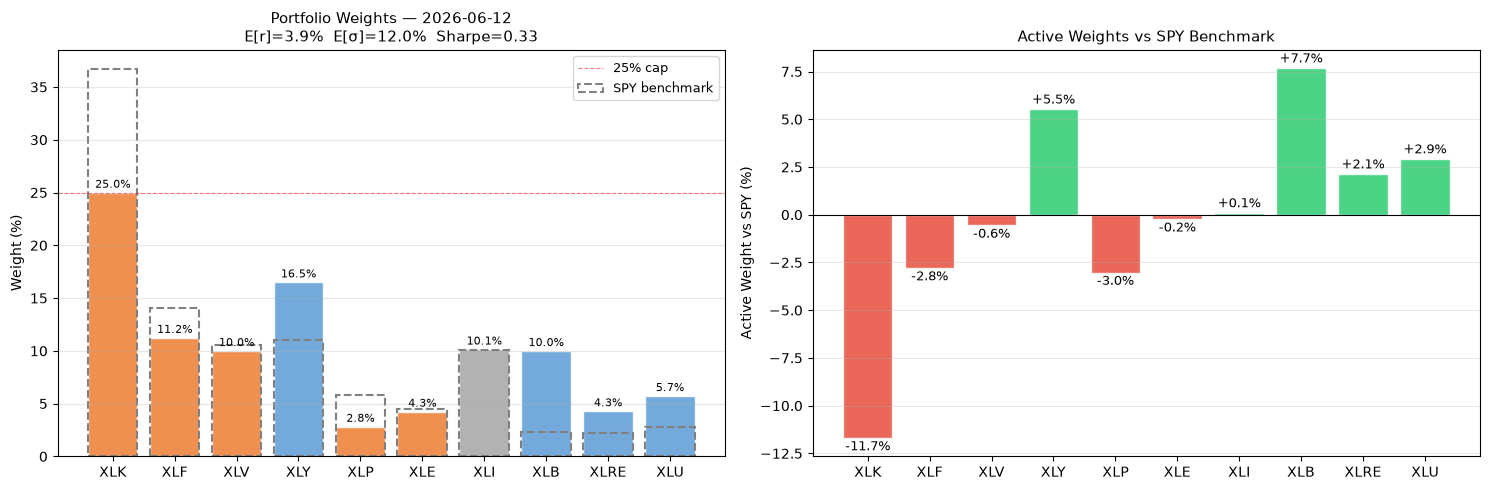

In [19]:
# ── Final portfolio bar chart ─────────────────────────────────────────────────
final_weights_pct = [result['weights'][t] * 100 for t in TICKERS]
spy_pct           = spy_weights * 100
diff_pct          = [fw - sw for fw, sw in zip(final_weights_pct, spy_pct)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: absolute weights
bar_colors = ['#5b9bd5' if d > 0.1 else '#ed7d31' if d < -0.1 else '#a5a5a5' for d in diff_pct]
axes[0].bar(range(N), final_weights_pct, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].bar(range(N), spy_pct, fill=False, edgecolor='grey', linewidth=1.5,
            label='SPY benchmark', linestyle='--')
axes[0].set_xticks(range(N)); axes[0].set_xticklabels(TICKERS, fontsize=10)
axes[0].set_ylabel('Weight (%)', fontsize=10)
axes[0].set_title(f'Portfolio Weights — {REBALANCE_DATE}\n'
                  f'E[r]={result["expected_return_annual"]*100:.1f}%  '
                  f'E[σ]={result["expected_vol_annual"]*100:.1f}%  '
                  f'Sharpe={result["expected_return_annual"]/result["expected_vol_annual"]:.2f}',
                  fontsize=11)
axes[0].axhline(25, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='25% cap')
for i, (fw, sw) in enumerate(zip(final_weights_pct, spy_pct)):
    axes[0].text(i, fw + 0.2, f'{fw:.1f}%', ha='center', va='bottom', fontsize=8)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Right: active weights (vs SPY benchmark)
act_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diff_pct]
bars = axes[1].bar(range(N), diff_pct, color=act_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(TICKERS, fontsize=10)
axes[1].set_ylabel('Active Weight vs SPY (%)', fontsize=10)
axes[1].set_title('Active Weights vs SPY Benchmark', fontsize=11)
for bar, d in zip(bars, diff_pct):
    ha = 'center'
    offset = 0.15 if d >= 0 else -0.15
    axes[1].text(bar.get_x() + bar.get_width()/2, d + offset,
                 f'{d:+.1f}%', ha=ha, va='bottom' if d >= 0 else 'top', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/exports/s6_final_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
import subprocess

_result = subprocess.run(
    [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html',
        '--output', 'exports/03_optimizer.html',
        '03_optimizer.ipynb',
    ],
    capture_output=True, text=True,
    cwd=str(Path('..') / 'notebooks'),
)
if _result.returncode == 0:
    print('✓ Exported to notebooks/exports/03_optimizer.html')
else:
    print('Export output:', _result.stdout or _result.stderr)


✓ Exported to notebooks/exports/03_optimizer.html
